The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Epoch 1/10: 100%|██████████| 36/36 [00:54<00:00,  1.50s/it]


  loss=0.9801  val_IoU=0.5486  val_Dice=0.6976


Epoch 2/10: 100%|██████████| 36/36 [00:52<00:00,  1.47s/it]


  loss=0.4208  val_IoU=0.6859  val_Dice=0.8013


...

  loss=0.2443  val_IoU=0.7738  val_Dice=0.8652


Epoch 10/10: 100%|██████████| 36/36 [00:37<00:00,  1.04s/it]


  loss=0.2298  val_IoU=0.7835  val_Dice=0.8719
Melhor IoU semântico (val): 0.7835
Dice correspondente:       0.8719


Avaliando instâncias: 100%|██████████| 7/7 [05:14<00:00, 44.92s/it]



AP por limiar de IoU:
  IoU=0.50: AP=0.4136
  IoU=0.55: AP=0.3854
  IoU=0.60: AP=0.3648
  IoU=0.65: AP=0.3440
  IoU=0.70: AP=0.3155
  IoU=0.75: AP=0.2744
  IoU=0.80: AP=0.2202
  IoU=0.85: AP=0.1508
  IoU=0.90: AP=0.0789
  IoU=0.95: AP=0.0206

mAP (0.50:0.95): 0.2568
Erro absoluto médio de contagem por imagem: 20.130


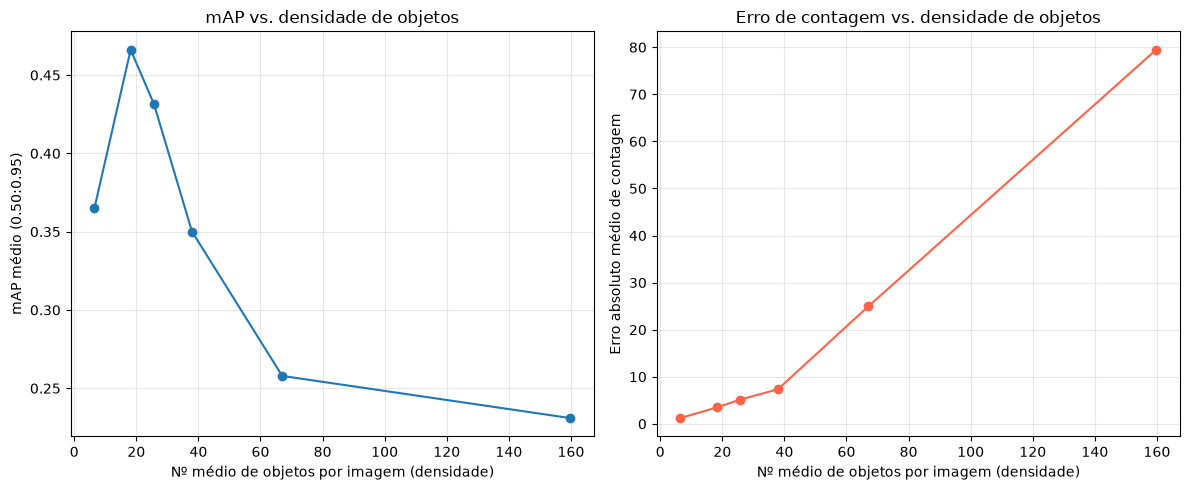

     density_bin   mean_n_gt  mean_mAP  mean_count_error  n_images
0  (0.999, 12.0]    6.500000  0.364907          1.222222        18
1   (12.0, 22.0]   18.176471  0.466182          3.470588        17
2   (22.0, 29.0]   25.687500  0.431492          5.125000        16
3   (29.0, 46.0]   37.941176  0.350044          7.352941        17
4   (46.0, 84.5]   67.000000  0.257895         24.933333        15
5  (84.5, 369.0]  159.764706  0.230959         79.470588        17


In [ ]:
# Importacao de arquivos
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import UNetBinary
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

# Configurações 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IMG_SIZE = 128
model = UNetBinary()
model.to(DEVICE)
path_train = Path('../data/stage1_train')
path_test = Path('../data/stage1_test')

# Estrutura esperada (padrão DSB2018):
#   root/<id>/images/<id>.png
#   root/<id>/masks/*.png   (uma máscara binária por instância)


class DSB2018Dataset(Dataset):
    def __init__(self, root, img_size=IMG_SIZE, augment=None):
        self.root = Path(root)
        self.ids = sorted([p.name for p in self.root.iterdir() if p.is_dir()])
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def _load_instance_masks(self, mask_dir):
        mask_files = sorted(mask_dir.glob('*.png'))
        masks = []
        for mf in mask_files:
            m = np.array(Image.open(mf).convert('L'))
            masks.append((m > 0).astype(np.uint8))
        return masks

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_path = self.root / img_id / 'images' / f'{img_id}.png'
        mask_dir = self.root / img_id / 'masks'

        image = np.array(Image.open(img_path).convert('RGB'))
        instance_masks = self._load_instance_masks(mask_dir)

        H, W = image.shape[:2]
        binary_mask = np.zeros((H, W), dtype=np.uint8)
        for m in instance_masks:
            binary_mask = np.maximum(binary_mask, m)

        image_r = cv2.resize(image, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_LINEAR)
        binary_mask_r = cv2.resize(binary_mask, (self.img_size, self.img_size),
                                    interpolation=cv2.INTER_NEAREST)

        if self.augment is not None:
            aug = self.augment(image=image_r, mask=binary_mask_r)
            image_r, binary_mask_r = aug['image'], aug['mask']

        image_t = torch.from_numpy(image_r / 255.0).permute(2, 0, 1).float()
        mask_t = torch.from_numpy(binary_mask_r.astype(np.float32)).unsqueeze(0)

        # instâncias redimensionadas junto (mantidas separadas p/ avaliação)
        instance_masks_r = [
            cv2.resize(m, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
            for m in instance_masks
        ]

        return image_t, mask_t, instance_masks_r, img_id


def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    instance_masks = [b[2] for b in batch]   # lista de listas (tam. variável)
    ids = [b[3] for b in batch]
    return images, masks, instance_masks, ids


# ---------------------------------------------------------------------------
# 1. Treino — BCE + Dice loss, e IoU/Dice como métricas semânticas
# ---------------------------------------------------------------------------

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def bce_dice_loss(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets) + dice_loss(logits, targets)

@torch.no_grad()
def compute_iou_dice(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter
    iou = (inter + eps) / (union + eps)
    dice = (2 * inter + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)
    return iou.mean().item(), dice.mean().item()


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                             factor=0.5, patience=3)
    history = {'train_loss': [], 'val_iou': [], 'val_dice': []}
    best_iou = -1

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, masks, _, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss = bce_dice_loss(logits, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        ious, dices = [], []
        with torch.no_grad():
            for images, masks, _, _ in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                iou, dice = compute_iou_dice(logits, masks)
                ious.append(iou)
                dices.append(dice)
        val_iou, val_dice = np.mean(ious), np.mean(dices)
        scheduler.step(val_iou)

        history['train_loss'].append(train_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)
        print(f'  loss={train_loss:.4f}  val_IoU={val_iou:.4f}  val_Dice={val_dice:.4f}')

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), 'best_model.pt')

    return history


# ---------------------------------------------------------------------------
# 2. Extração de instâncias ingênua: limiar + componentes conexos
# ---------------------------------------------------------------------------

def extract_instances(prob_map, threshold=0.5, min_size=5):
    """
    prob_map: array HxW de probabilidades (saída do sigmoid).
    Retorna lista de máscaras binárias HxW, uma por componente conexa
    (conectividade 8, via scipy.ndimage.label), descartando ruído < min_size px.
    """
    binary = (prob_map > threshold).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)  # conectividade-8
    labeled, num = ndimage.label(binary, structure=structure)
    instances = []
    for i in range(1, num + 1):
        inst_mask = (labeled == i).astype(np.uint8)
        if inst_mask.sum() >= min_size:
            instances.append(inst_mask)
    return instances


# ---------------------------------------------------------------------------
# 3 e 4. Avaliação como instâncias — matching guloso por IoU decrescente
# ---------------------------------------------------------------------------
#
# REGRA DE MATCHING (documentada, escolha do grupo): guloso por IoU decrescente.
#   1. Calcula a matriz de IoU (pred x gt) entre todas as máscaras preditas
#      e todas as máscaras verdadeiras da imagem.
#   2. Lista todos os pares (pred, gt) com seu IoU e ordena por IoU decrescente.
#   3. Percorre a lista em ordem; casa o par se IoU >= limiar do momento E se
#      nem a predição nem o GT já foram usados em outro casamento.
#   4. Predições não casadas => FP. GTs não casados => FN. Pares casados => TP.
#      Cada instância prevista casa com NO MÁXIMO uma verdadeira, e vice-versa.
#
# (Alternativa seria o algoritmo Hungarian/linear_sum_assignment, que resolve
#  o casamento ótimo global em vez de guloso; optamos pelo guloso por ser o
#  padrão adotado na métrica oficial do próprio DSB2018 e por não exigir
#  matriz de custo quadrada/completa.)

def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    if union == 0:
        return 0.0
    return inter / union

def greedy_match(pred_masks, gt_masks, iou_threshold):
    n_pred, n_gt = len(pred_masks), len(gt_masks)
    if n_pred == 0 and n_gt == 0:
        return 0, 0, 0
    if n_pred == 0:
        return 0, 0, n_gt
    if n_gt == 0:
        return 0, n_pred, 0

    iou_matrix = np.zeros((n_pred, n_gt))
    for i, pm in enumerate(pred_masks):
        for j, gm in enumerate(gt_masks):
            iou_matrix[i, j] = mask_iou(pm, gm)

    pairs = [(iou_matrix[i, j], i, j) for i in range(n_pred) for j in range(n_gt)]
    pairs.sort(key=lambda x: -x[0])

    matched_pred, matched_gt = set(), set()
    tp = 0
    for iou, i, j in pairs:
        if iou < iou_threshold:
            break
        if i in matched_pred or j in matched_gt:
            continue
        matched_pred.add(i)
        matched_gt.add(j)
        tp += 1

    fp = n_pred - tp
    fn = n_gt - tp
    return tp, fp, fn


# AP por limiar: como o método ingênuo (limiar + componentes conexos) não
# produz um score de confiança por instância, não há curva precisão-recall
# para integrar. Seguimos a métrica oficial do DSB2018: em cada limiar de
# IoU, AP = TP / (TP + FP + FN), agregado sobre TODAS as imagens do split.
# mAP = média de AP sobre os limiares 0.50:0.95:0.05.

IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)  # 0.50, 0.55, ..., 0.95

@torch.no_grad()
def evaluate_instances(model, loader, prob_threshold=0.5, min_size=5):
    model.eval()

    # acumuladores globais por limiar de IoU (para AP agregado do dataset)
    agg = {t: {'tp': 0, 'fp': 0, 'fn': 0} for t in IOU_THRESHOLDS}

    # registros por imagem (para o gráfico de densidade e o erro de contagem)
    per_image_records = []

    for images, _, instance_masks_batch, ids in tqdm(loader, desc='Avaliando instâncias'):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()  # (B,1,H,W)

        for b in range(images.size(0)):
            prob_map = probs[b, 0]
            gt_masks = instance_masks_batch[b]
            pred_masks = extract_instances(prob_map, prob_threshold, min_size)

            n_gt, n_pred = len(gt_masks), len(pred_masks)
            count_error = abs(n_pred - n_gt)

            ap_per_threshold = []
            for t in IOU_THRESHOLDS:
                tp, fp, fn = greedy_match(pred_masks, gt_masks, t)
                agg[t]['tp'] += tp
                agg[t]['fp'] += fp
                agg[t]['fn'] += fn
                denom = tp + fp + fn
                ap_img = tp / denom if denom > 0 else 1.0  # sem obj. e sem pred. = acerto
                ap_per_threshold.append(ap_img)

            per_image_records.append({
                'id': ids[b],
                'n_gt': n_gt,
                'n_pred': n_pred,
                'count_error': count_error,
                'mAP_image': float(np.mean(ap_per_threshold)),
            })

    # AP agregado por limiar (sobre o dataset todo) + mAP final
    ap_by_threshold = {}
    for t in IOU_THRESHOLDS:
        tp, fp, fn = agg[t]['tp'], agg[t]['fp'], agg[t]['fn']
        denom = tp + fp + fn
        ap_by_threshold[round(t, 2)] = tp / denom if denom > 0 else 1.0
    mAP = float(np.mean(list(ap_by_threshold.values())))

    df = pd.DataFrame(per_image_records)
    mean_count_error = df['count_error'].mean()

    return {
        'ap_by_threshold': ap_by_threshold,
        'mAP': mAP,
        'mean_count_error': mean_count_error,
        'per_image_df': df,
    }


# ---------------------------------------------------------------------------
# 5. Fracasso em função da densidade de objetos por imagem
# ---------------------------------------------------------------------------

def plot_density_failure(df, n_bins=6, out_path='density_vs_failure.png'):
    """
    df precisa ter colunas: n_gt, count_error, mAP_image.
    Agrupa imagens em faixas (bins) de densidade (n_gt) e plota
    a média de mAP e do erro de contagem por faixa.
    """
    df = df.copy()
    df['density_bin'] = pd.qcut(df['n_gt'], q=min(n_bins, df['n_gt'].nunique()),
                                 duplicates='drop')
    grouped = df.groupby('density_bin', observed=True).agg(
        mean_n_gt=('n_gt', 'mean'),
        mean_mAP=('mAP_image', 'mean'),
        mean_count_error=('count_error', 'mean'),
        n_images=('id', 'count'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(grouped['mean_n_gt'], grouped['mean_mAP'], marker='o')
    axes[0].set_xlabel('Nº médio de objetos por imagem (densidade)')
    axes[0].set_ylabel('mAP médio (0.50:0.95)')
    axes[0].set_title('mAP vs. densidade de objetos')
    axes[0].grid(alpha=0.3)

    axes[1].plot(grouped['mean_n_gt'], grouped['mean_count_error'], marker='o', color='tomato')
    axes[1].set_xlabel('Nº médio de objetos por imagem (densidade)')
    axes[1].set_ylabel('Erro absoluto médio de contagem')
    axes[1].set_title('Erro de contagem vs. densidade de objetos')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

    return grouped


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

if __name__ == '__main__':
    full_train_ds = DSB2018Dataset(path_train)

    # split simples treino/val (ex.: 85/15)
    n = len(full_train_ds)
    n_val = int(0.15 * n)
    n_train = n - n_val
    train_ds, val_ds = torch.utils.data.random_split(
        full_train_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                               collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                             collate_fn=collate_fn)

    # 1) treino + métricas semânticas
    history = train_model(model, train_loader, val_loader, epochs=10, lr=1e-3)
    print(f"Melhor IoU semântico (val): {max(history['val_iou']):.4f}")
    print(f"Dice correspondente:       {history['val_dice'][-1]:.4f}")

    model.load_state_dict(torch.load('best_model.pt'))

    # 2-4) extração ingênua de instâncias + avaliação como instâncias
    results = evaluate_instances(model, val_loader, prob_threshold=0.5, min_size=5)

    print('\nAP por limiar de IoU:')
    for t, ap in results['ap_by_threshold'].items():
        print(f'  IoU={t:.2f}: AP={ap:.4f}')
    print(f"\nmAP (0.50:0.95): {results['mAP']:.4f}")
    print(f"Erro absoluto médio de contagem por imagem: {results['mean_count_error']:.3f}")

    # 5) fracasso vs. densidade
    grouped = plot_density_failure(results['per_image_df'])
    print(grouped)

    results['per_image_df'].to_csv('instance_eval_per_image.csv', index=False)